<a href="https://colab.research.google.com/github/Heethashreesathish/Java-Programs/blob/main/Pedestrian_Detection_using_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
karthika95_pedestrian_detection_path = kagglehub.dataset_download('karthika95/pedestrian-detection')

print('Data source import complete.')


Using Colab cache for faster access to the 'pedestrian-detection' dataset.
Data source import complete.


In [28]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import cv2
import os
from xml.etree import ElementTree
from matplotlib import pyplot as plt
# Any results you write to the current directory are saved as output.

In [29]:
#%tensorflow_version 2.x  # this line is not required unless you are in a notebook
import tensorflow as tf
from sklearn.metrics import confusion_matrix
from tensorflow.keras import datasets, layers, models
keras = tf.keras

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


In [30]:
class_names = ['person','person-like']
class_names_label = {class_name:i for i, class_name in enumerate(class_names)}

n_classes = 2
size = (200,200)

In [31]:
def load_data():
    datasets = ['Train/Train', 'Test/Test', 'Val/Val']
    output = []

    for dataset in datasets:
        imags = []
        labels = []
        directoryA = "/kaggle/input/pedestrian-detection/" + dataset +"/Annotations"
        directoryIMG = "/kaggle/input/pedestrian-detection/" + dataset +"/JPEGImages/"
        file = os.listdir(directoryA)
        img = os.listdir(directoryIMG)
        file.sort()
        img.sort()

        i = 0
        for xml in file:

            xmlf = os.path.join(directoryA,xml)
            dom = ElementTree.parse(xmlf)
            vb = dom.findall('object')
            label = vb[0].find('name').text
            labels.append(class_names_label[label])

            img_path = directoryIMG + img[i]
            curr_img = cv2.imread(img_path)
            curr_img = cv2.resize(curr_img, size)
            imags.append(curr_img)
            i +=1

        imags = np.array(imags, dtype='float32')
        imags = imags / 255

      #  labels = pd.DataFrame(labels)
        labels = np.array(labels, dtype='int32')

        output.append((imags, labels))
    return output




In [32]:
(train_images, train_labels),(test_images, test_labels),(val_images, val_labels) = load_data()

In [33]:
train_images.shape

(944, 200, 200, 3)

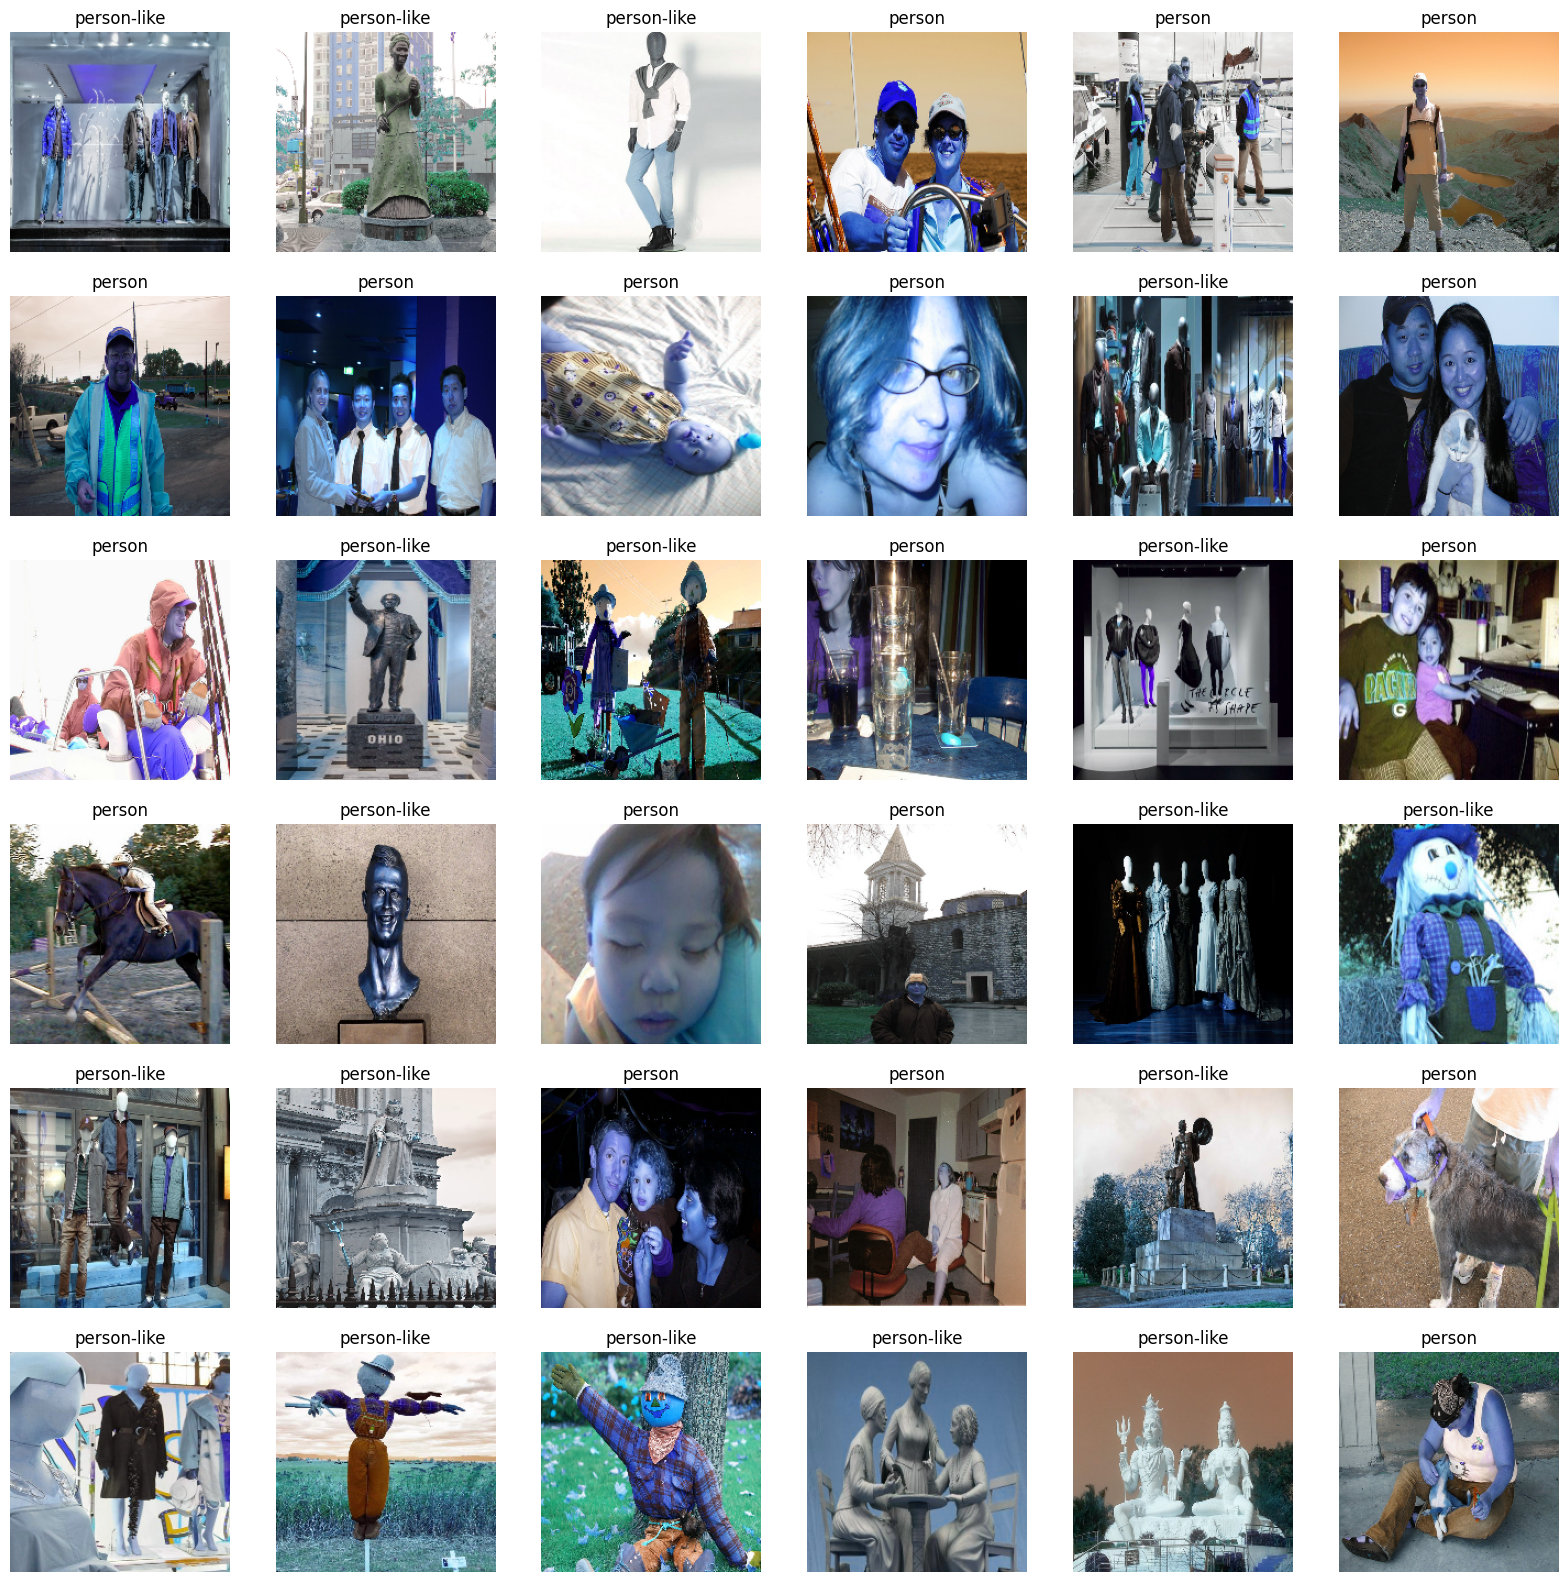

In [34]:
plt.figure(figsize=(20,20))
for n , i in enumerate(list(np.random.randint(0,len(train_images),36))) :
    plt.subplot(6,6,n+1)
    plt.imshow(train_images[i])
    plt.title(class_names[train_labels[i]])
    plt.axis('off')

In [35]:
model = models.Sequential()
model.add(layers.Conv2D(16, (3, 3), activation='relu', input_shape=(200, 200, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(32, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [36]:
model.add(layers.Flatten())
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dense(2))

In [37]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [38]:
history = model.fit(train_images, train_labels, epochs=6,
                    validation_data=(test_images, test_labels))

Epoch 1/6
30/30 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - accuracy: 0.5252 - loss: 2.2298 - val_accuracy: 0.5787 - val_loss: 0.6613
Epoch 2/6
30/30 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.5967 - loss: 0.6441 - val_accuracy: 0.5702 - val_loss: 0.6549
Epoch 3/6
30/30 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.6932 - loss: 0.5533 - val_accuracy: 0.6170 - val_loss: 0.6166
Epoch 4/6
30/30 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.8524 - loss: 0.3488 - val_accuracy: 0.6255 - val_loss: 0.6254
Epoch 5/6
30/30 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.9430 - loss: 0.1832 - val_accuracy: 0.6723 - val_loss: 0.7143
Epoch 6/6
30/30 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.9927 - loss: 0.0500 - val_accuracy: 0.7021 - val_loss: 0.8674


In [39]:
def plot_accuracy_loss(history):
    """
        Plot the accuracy and the loss during the training of the nn.
    """
    fig = plt.figure(figsize=(10,5))

    # Plot accuracy
    plt.subplot(221)
    plt.plot(history.history['accuracy'],'bo--', label = "acc")
    plt.plot(history.history['val_accuracy'], 'ro--', label = "val_acc")
    plt.title("train_acc vs val_acc")
    plt.ylabel("accuracy")
    plt.xlabel("epochs")
    plt.legend()

    # Plot loss function
    plt.subplot(222)
    plt.plot(history.history['loss'],'bo--', label = "loss")
    plt.plot(history.history['val_loss'], 'ro--', label = "val_loss")
    plt.title("train_loss vs val_loss")
    plt.ylabel("loss")
    plt.xlabel("epochs")

    plt.legend()
    plt.show()

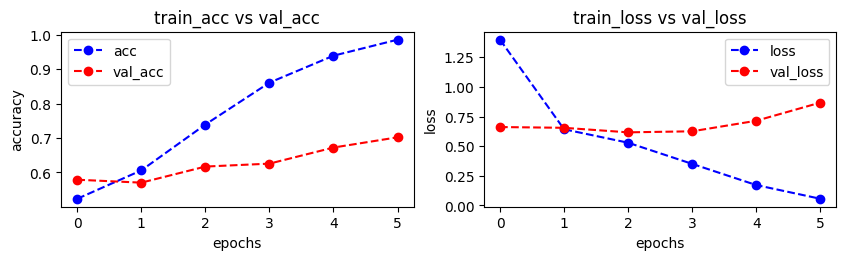

In [40]:
plot_accuracy_loss(history)

In [41]:
preds = model.predict(val_images)

5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 504ms/step


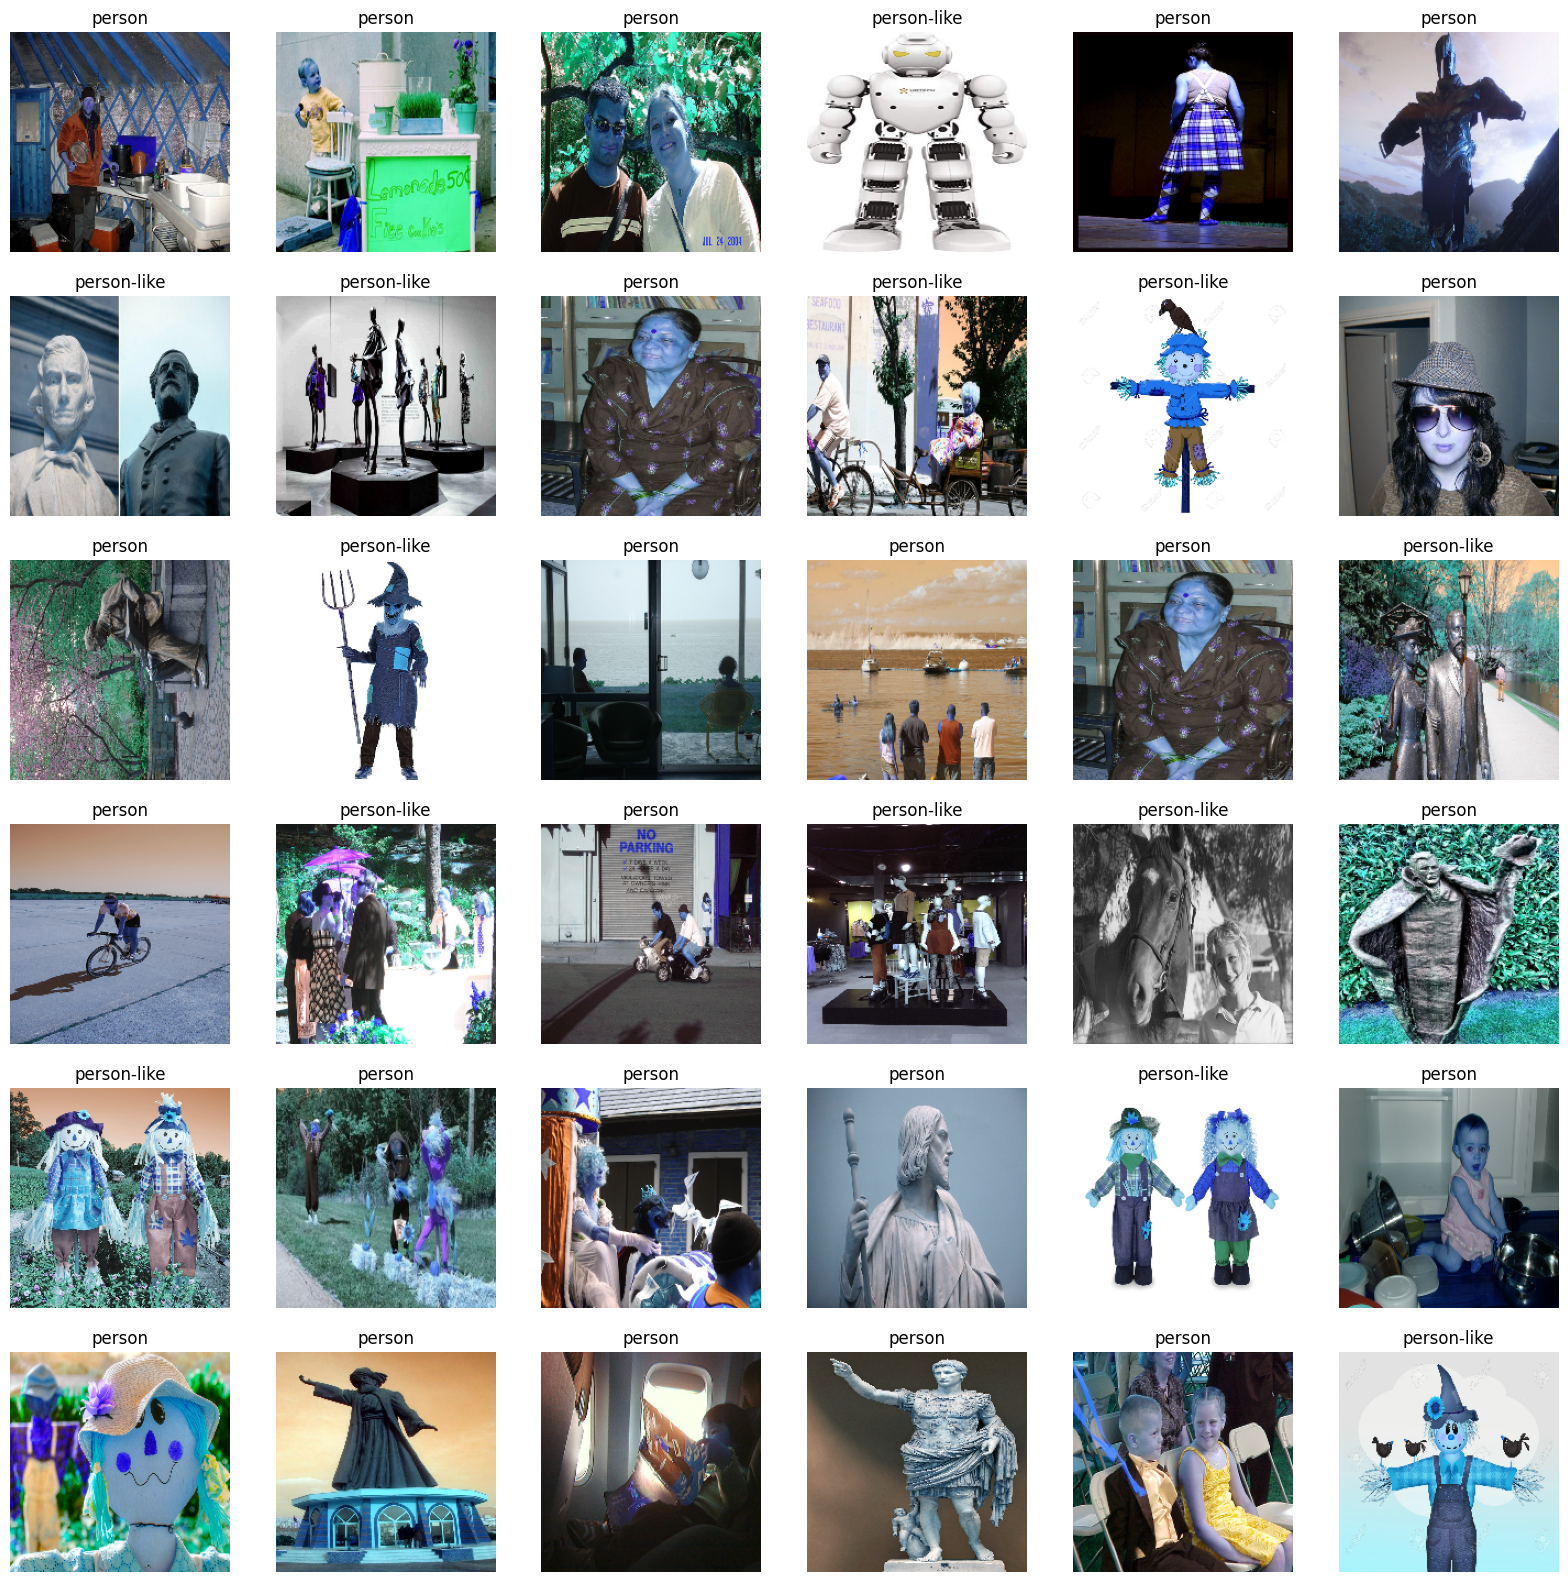

In [42]:
plt.figure(figsize=(20,20))
for n , i in enumerate(list(np.random.randint(0,len(val_images),36))) :
    plt.subplot(6,6,n+1)
    plt.imshow(val_images[i])
    plt.axis('off')
    x =np.argmax(preds[i]) # takes the maximum of of the 6 probabilites.
    plt.title((class_names[x]))

In [43]:
result = []
for i in range(len(preds)):
    result.append(np.argmax(preds[i]))

In [44]:
tn, fp, fn, tp = confusion_matrix(val_labels,result).ravel()

In [45]:
(tn, fp, fn, tp)

(np.int64(73), np.int64(12), np.int64(33), np.int64(42))